In [ ]:
%load_ext autoreload
%autoreload 2
%matplotlib inline
%cd ..

/workspaces/API-macroecon-wrappy


In [ ]:
import sys
sys.path.append('/workspaces/API-macroecon-wrappy')

In [ ]:
from macroecon_wrappy import Auth, Metric

import pandas as pd
import QuantLib as ql

from pathlib import Path
import pprint

secrets_path = Path('/workspaces/API-macroecon-wrappy/SECRETS.yaml')
cache_path = Path('/workspaces/API-macroecon-wrappy/tests/tmp/')
auth = Auth(secrets_path, cache_path)
auth.load_secrets()

True

## Current Yield Curve

### Load data

In [ ]:
#current yield curve
df_curve = auth.obb.fixedincome.government.yield_curve(
    country="united_states", 
    date="2026-06-11",
    provider="federal_reserve"
)
df_curve.shape

(11, 3)

In [56]:
df_curve.head()

,maturity,rate,maturity_years
date,,,
2026-06-11,month_1,0.0369,0.083333
2026-06-11,month_3,0.0378,0.250000
2026-06-11,month_6,0.0381,0.500000
2026-06-11,year_1,0.0385,1.000000
2026-06-11,year_2,0.0405,2.000000


In [ ]:
#historical rates
historical_rates_obj = auth.obb.fixedincome.government.treasury_rates(
    country="united_states", 
    start_date="1962-01-02",
    provider="federal_reserve"
)

df_rates = (
    historical_rates_obj.to_df() 
    if hasattr(historical_rates_obj, 'to_df') 
    else pd.DataFrame(historical_rates_obj)
)
df_rates.index = pd.to_datetime(df_rates.index)

print(df_rates.head())

            year_1  year_3  year_5  year_10  year_20  year_7  year_2  year_30  \
date                                                                            
1962-01-02  0.0322  0.0370  0.0388   0.0406   0.0407     NaN     NaN      NaN   
1962-01-03  0.0324  0.0370  0.0387   0.0403   0.0407     NaN     NaN      NaN   
1962-01-04  0.0324  0.0369  0.0386   0.0399   0.0406     NaN     NaN      NaN   
1962-01-05  0.0326  0.0371  0.0389   0.0402   0.0407     NaN     NaN      NaN   
1962-01-08  0.0331  0.0371  0.0391   0.0403   0.0408     NaN     NaN      NaN   

            month_3  month_6  month_1  
date                                   
1962-01-02      NaN      NaN      NaN  
1962-01-03      NaN      NaN      NaN  
1962-01-04      NaN      NaN      NaN  
1962-01-05      NaN      NaN      NaN  
1962-01-08      NaN      NaN      NaN  


In [ ]:
#validate current yield curve from historical data
#transform from wide to long
df_curve_from_historical = pd.melt(
    df_rates.loc[['2026-06-11']].reset_index(),         # Reset index to make 'date' an accessible column
    id_vars=['date'],               # Column(s) to keep as identifiers
    var_name='maturity',            # Name for the new column holding the old headers
    value_name='yield'              # Name for the new column holding the values
)
df_curve_from_historical.shape

(11, 3)

In [ ]:
#validation
df_curve_from_historical

,date,maturity,yield
0,2026-06-11,year_1,0.0385
1,2026-06-11,year_3,0.0409
2,2026-06-11,year_5,0.0418
3,2026-06-11,year_10,0.0445
4,2026-06-11,year_20,0.0496
5,2026-06-11,year_7,0.0431
6,2026-06-11,year_2,0.0405
7,2026-06-11,year_30,0.0495
8,2026-06-11,month_3,0.0378
9,2026-06-11,month_6,0.0381


### Build Term Structure

In [109]:
# 1. OpenBB yields are typically in percentages (e.g., 4.5), QuantLib expects decimals (0.045)
nominal_rates = df_curve['rate'].tolist()   #(df_curve['rate'] / 100.0).tolist()

# 2. Setup QuantLib environment
calendar = ql.UnitedStates(ql.UnitedStates.GovernmentBond)
today = ql.DateParser.parseISO('2026-06-11')
ql.Settings.instance().evaluationDate = today

# 3. Map maturities to exact future target dates in QuantLib
dates = [today] # Curve starts today
for m in df_curve['maturity_years']:
    # Convert fractional years to days or months roughly
    days = int(m * 365)
    dates.append(calendar.advance(today, ql.Period(days, ql.Days)))

# Prepend a spot rate for 'today' (usually matching the shortest maturity rate)
rates = [nominal_rates[0]] + nominal_rates

In [ ]:
# 4. Instantiate the QuantLib YieldTermStructure
day_count = ql.Actual360()
compounding = ql.Continuous
compounding_frequency = ql.Annual

yield_term_structure = ql.ZeroCurve(
    dates, 
    rates, 
    day_count, 
    calendar,
    ql.Linear(), # Interpolation type
    compounding, 
    compounding_frequency
)
yield_term_structure.enableExtrapolation()

In QuantLib, zeroRate is a method that returns the zero-coupon interest rate (also known as the spot rate) for a specific date or time from an interest rate yield curve.Under the hood, QuantLib performs calculations primarily using discount factors. When you call zeroRate, the library converts the discount factor at the requested point into an equivalent implied interest rate based on your chosen compounding and day-counting rules.

QuantLib computes the returned InterestRate object directly from the discount factor (DF) using the underlying financial formulas. For example, if you ask for a continuously compounded zero rate (r) for a time t, QuantLib solves the standard equation:

$$
DF(t)=e^{-r\cdot t}\implies r=-\frac{\ln (DF(t))}{t}
$$

If you change the parameter to ql.Compounded with an annual frequency, it uses:

$$
DF(t)=\frac{1}{(1+r)^{t}}\implies r=\left(\frac{1}{DF(t)}\right)^{\frac{1}{t}}-1
$$

In [ ]:
# 5. Utilize the Term Structure object
# Automatically interpolates a rate for an exact point, e.g., 1.5 years out
target_date = calendar.advance(today, ql.Period(18, ql.Months))
zero_rate = yield_term_structure.zeroRate(target_date, day_count, compounding).rate()

print(f"Interpolated 18-Month Zero Rate: {zero_rate * 100:.4f}%")

Interpolated 18-Month Zero Rate: 3.8549%


The US Treasury Department's curve is a smoothed, calculated model that estimates what the market yield would be for a theoretical, highly liquid bond at precise, standard maturity intervals.

The US Treasury curve is constructed using a specific mathematical model—the quasi-cubic hermite spline function—to filter out market noise and create a clean visual line. It differs from individual security yields due to three structural factors:Constant Maturities vs. Fixed Dates: 

* The official yield curve reports yields for exact "Constant Maturities" (e.g., exactly 2, 5, or 10 years). Actual outstanding Treasury bonds mature on specific calendar dates, meaning their remaining lifetimes shrink every day and rarely land exactly on a round, multi-year marker.
* On-the-Run vs. Off-the-Run Securities: The Treasury Department builds its curve using only "On-the-Run" securities—the most recently issued, highly liquid bonds in each maturity category. Older bonds ("Off-the-Run") often trade at slightly different yields due to lower liquidity and varying coupon rates, causing them to sit slightly above or below the official curve line.
* The "Booster Shot" Exception: When the Treasury issues a brand new, highly anticipated bond (like a new 10-year note), surging demand can artificially drive its price up and its yield down. The smoothing model intentionally flattens out these individual security anomalies to present a unified economic baseline

In [ ]:
# Raw input variables extracted from your original OpenBB data pull
maturities_input = df_curve['maturity_years']
rates_input      = df_curve['rate']

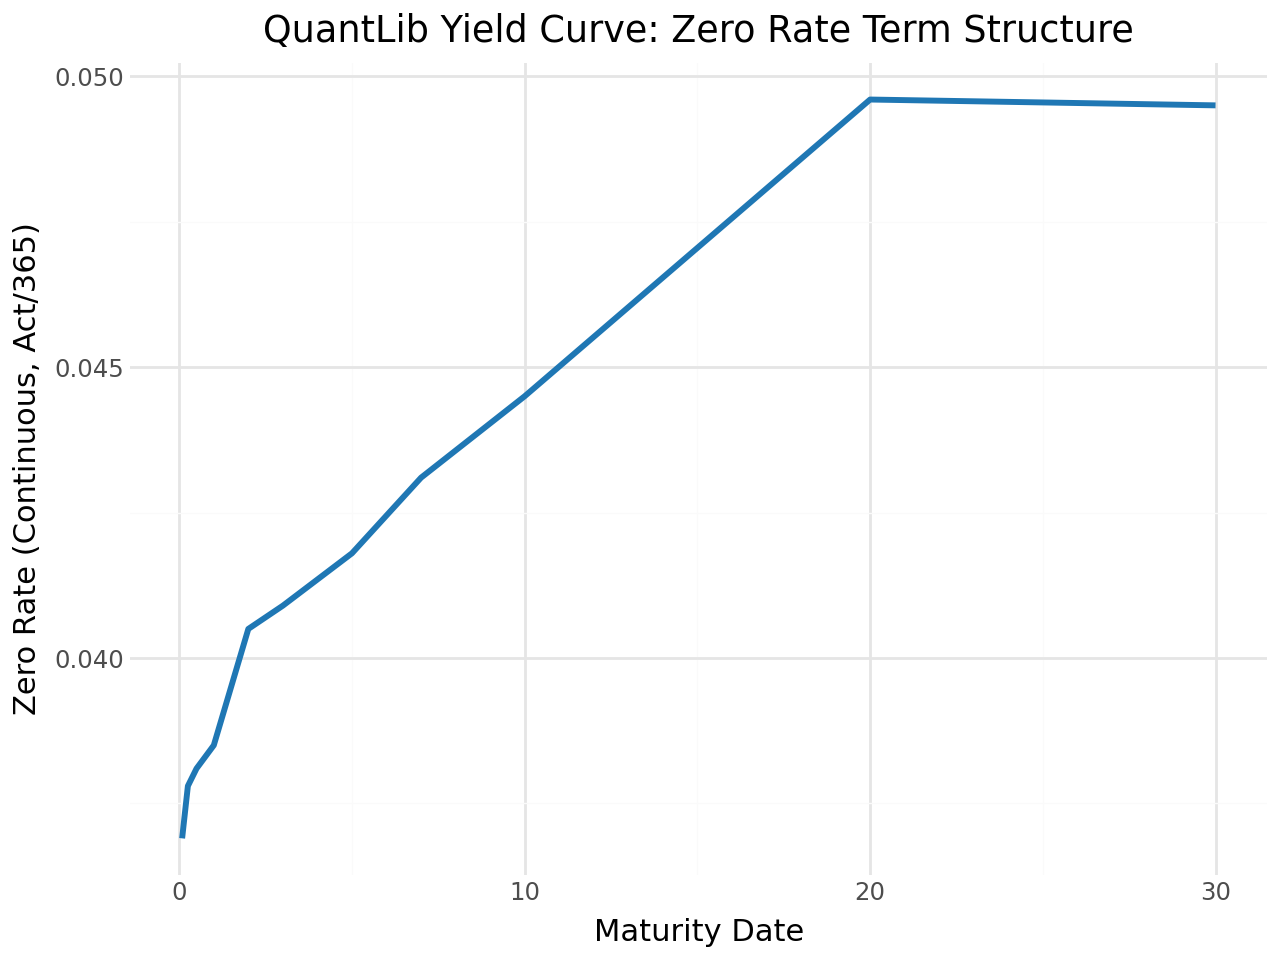

In [118]:
from plotnine import ggplot, aes, geom_line, geom_point, labs, theme_minimal, theme, element_text, scale_x_continuous

curve_plot = (
    ggplot(df_curve, aes(x='maturity_years', y='rate'))
    + geom_line(color='#1f77b4', size=1.2)
    + theme_minimal()
    + labs(
        title='QuantLib Yield Curve: Zero Rate Term Structure',
        x='Maturity Date',
        y='Zero Rate (Continuous, Act/365)'
    )
)

curve_plot

By default, Bloomberg terminals use a variable piecewise-linear scale on the X-axis (tenor) rather than a mathematically strict calendar linear or logarithmic scale.To maximize screen space and visual clarity, Bloomberg splits the X-axis spacing into unequal intervals optimized for fixed-income data density.

1. Spacing MechanicsIn a true linear date scale, the distance between the 1-Month and 1-Year tenors (11 months) would be identical to the distance between the 9-Year and 10-Year tenors. On a Bloomberg screen, this would compress the highly volatile "front end" of the curve into a tiny, unreadable corner while leaving massive gaps on the long end.To solve this, Bloomberg adjusts the distance between baseline tick marks dynamically:
  * The Front End (0 to 1 Year): Spaced out widely to clearly display money market instruments like Cash Deposits, Fed Funds, and OIS/STIR futures (1M, 3M, 6M).
  * The Belly (1 to 10 Years): Stepped down to standard annual sizing to showcase liquid benchmarks (2Y, 3Y, 5Y, 7Y, 10Y).
  * The Long End (10 to 30+ Years): Compressed heavily into broader multi-year intervals (e.g., the visual gap between 10Y and 20Y is roughly the same physical width as the gap between 2Y and 5Y).
2. User-Definable TogglesWhile the default view provides this human-optimized, segmented compression, users can change the behavior using top-menu dropdown toggles inside the GC or YCRV functions:
  * Constant Spacing: Every data point/helper instrument on the curve is given equal horizontal real estate, regardless of the time gap between them.
  * True Calendar Linear: Forces a exact mathematically linear time axis (mostly used when exporting data or analyzing precise curve convexity/duration visually).

How to Replicate It in Python (plotnine)If you want to move away from the basic daily linear timeline we built in the first prompt and mirror Bloomberg's front-end spacing logic, you can feed a non-linear scale to your ggplot object by mapping Time-to-Maturity (in years) as a numeric scale and explicitly defining uneven breaks:

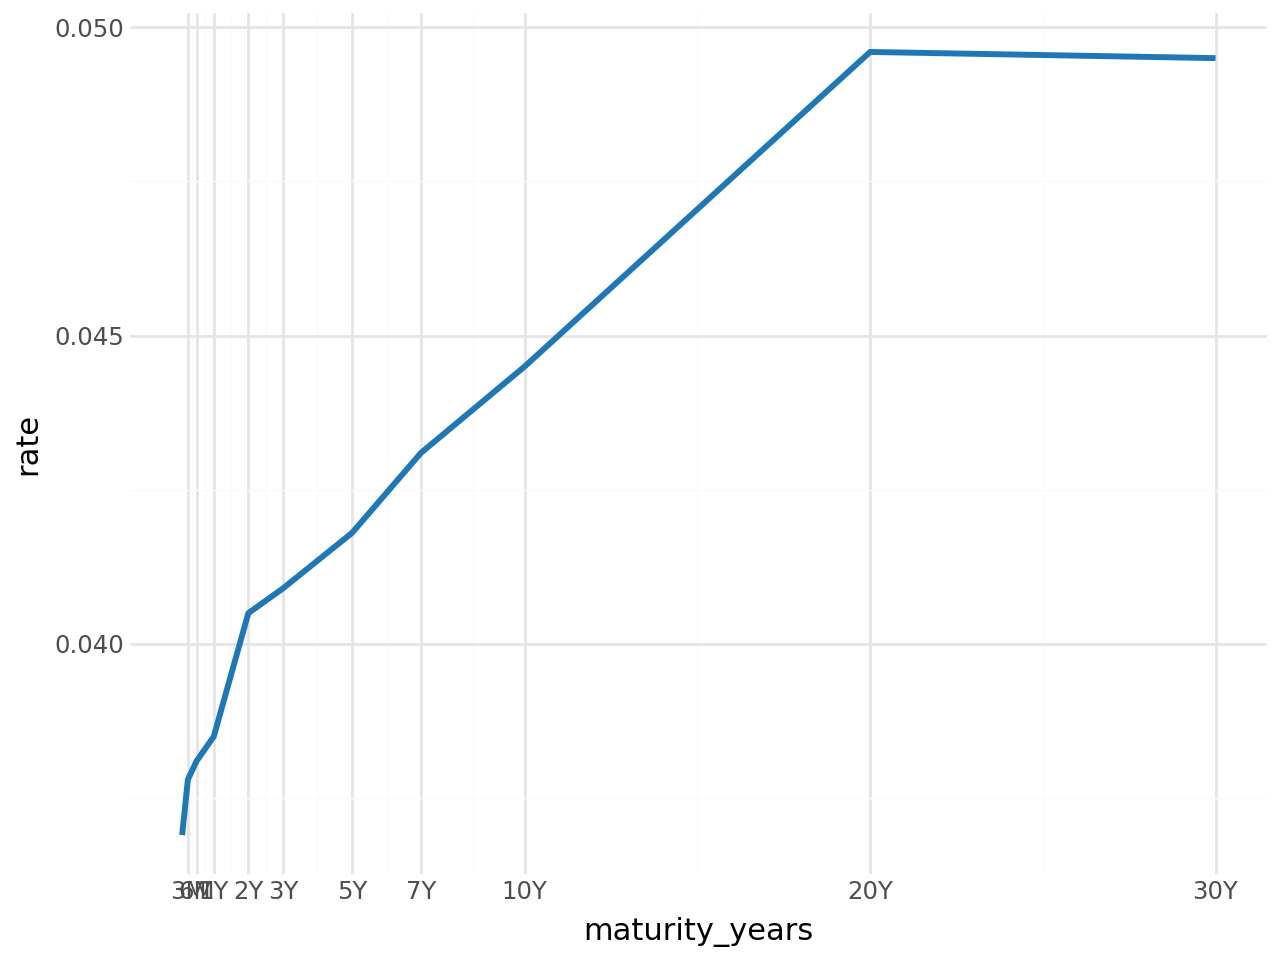

In [120]:
from plotnine import scale_x_continuous

curve_plot = (
    ggplot(df_curve, aes(x='maturity_years', y='rate'))
    + geom_line(color='#1f77b4', size=1.2)
    + theme_minimal()
    # Define exact uneven visual boundaries mirroring terminal layouts
    + scale_x_continuous(
        breaks=[0.25, 0.5, 1, 2, 3, 5, 7, 10, 20, 30],
        labels=['3M', '6M', '1Y', '2Y', '3Y', '5Y', '7Y', '10Y', '20Y', '30Y']
    )
)

curve_plot

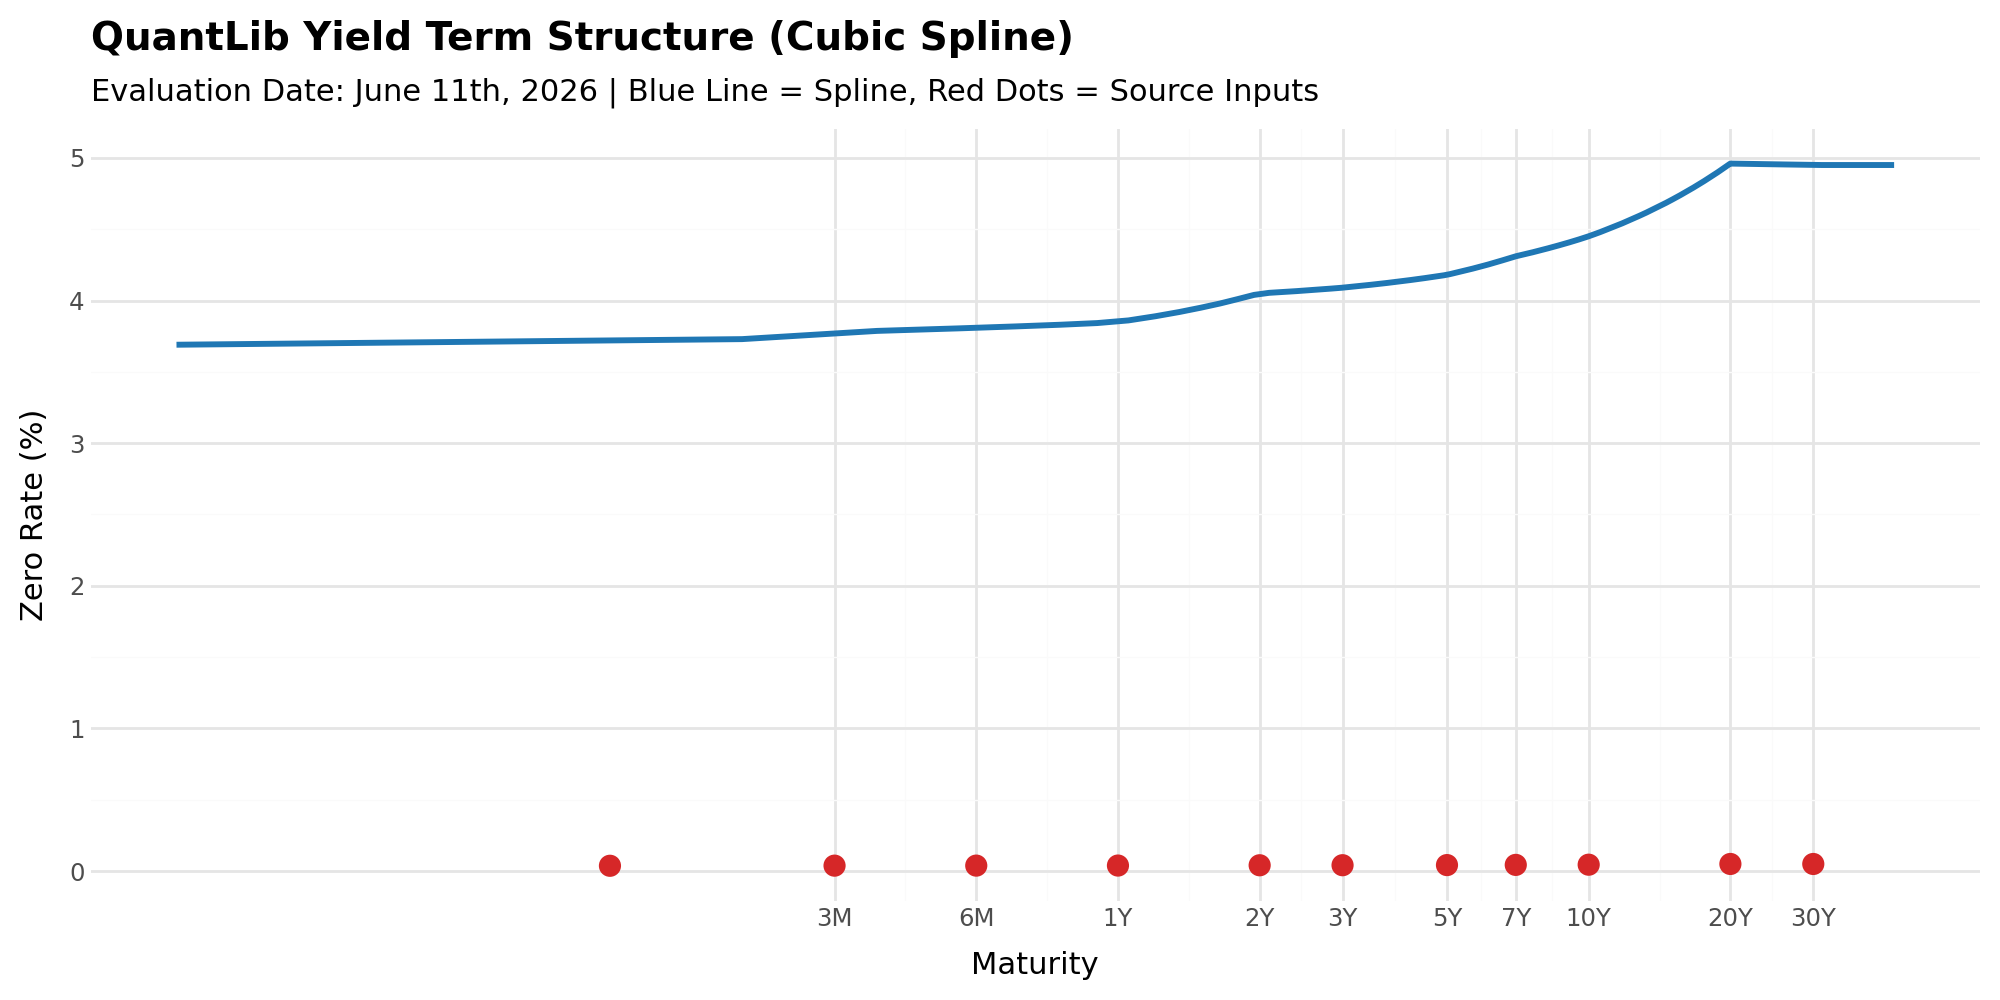

In [ ]:
visual_plot = plot_quantlib_log_curve_with_points(
    yield_term_structure=yield_term_structure, 
    raw_maturities=maturities_input, 
    raw_rates=rates_input
)
visual_plot.show()

### Functions

In [ ]:

from plotnine import ggplot, aes, geom_line, geom_point, labs, theme_minimal, theme, element_text, scale_x_continuous

def plot_quantlib_log_curve_with_points(yield_term_structure, raw_maturities, raw_rates, num_points=300):
    """
    Plots a QuantLib YieldTermStructure on a natural log scale using plotnine.
    Overlays original benchmark node inputs as distinct scatter points.
    
    Parameters:
    -----------
    yield_term_structure : ql.YieldTermStructure
    raw_maturities : list or np.array
        The original timeline node positions in fractional years (e.g. [0.25, 2.0, 10.0])
    raw_rates : list or np.array
        The original input nominal rates in percentage format (e.g. [4.25, 4.30, 4.22])
    """
    # 1. Setup internal QuantLib parameters based on current evaluation date
    today = ql.Settings.instance().evaluationDate
    calendar = ql.UnitedStates(ql.UnitedStates.GovernmentBond)
    day_count = ql.Actual360()
    
    # Safely find the curve boundaries
    max_date = yield_term_structure.maxDate()
    max_years = day_count.yearFraction(today, max_date)
    
    # 2. Extract continuous data from QuantLib for the line plot
    time_grid = np.linspace(0.01, max_years, num_points)
    line_data = []
    
    for t in time_grid:
        days = int(t * 365.25)
        future_date = calendar.advance(today, ql.Period(days, ql.Days))
        
        if future_date > max_date:
            future_date = max_date
            
        zero_rate_obj = yield_term_structure.zeroRate(future_date, day_count, ql.Continuous)
        rate_percent = zero_rate_obj.rate() * 100
        line_data.append({"Maturity": t, "Rate": rate_percent})
        
    df_line = pd.DataFrame(line_data)
    df_line["Log_Maturity"] = np.log(df_line["Maturity"])
    
    # 3. Pack original inputs into a separate dataframe for scatter plotting
    df_points = pd.DataFrame({
        "Maturity": raw_maturities,
        "Rate": raw_rates
    })
    # Transform raw maturities to the exact same log space coordinates
    df_points["Log_Maturity"] = np.log(df_points["Maturity"])
    
    # 4. Setup clean maturity milestone targets for the X-axis
    benchmark_maturities = [0.25, 0.5, 1.0, 2.0, 3.0, 5.0, 7.0, 10.0, 20.0, 30.0]
    clean_tick_labels = ["3M", "6M", "1Y", "2Y", "3Y", "5Y", "7Y", "10Y", "20Y", "30Y"]
    
    # Filter milestones to prevent looking past the max timeline of the curve object
    final_breaks = [b for b in benchmark_maturities if b <= max_years]
    final_labels = clean_tick_labels[:len(final_breaks)]
    log_space_breaks = [np.log(b) for b in final_breaks]
    
    # Create mapping table for formatting
    label_mapping_table = dict(zip(log_space_breaks, final_labels))
    
    def clean_axis_formatter(x_axis_values):
        output_string_labels = []
        for coordinate in x_axis_values:
            matched_text = None
            for target_log_break, label_string in label_mapping_table.items():
                if np.isclose(coordinate, target_log_break, atol=1e-1):
                    matched_text = label_string
                    break
            output_string_labels.append(matched_text if matched_text else "")
        return output_string_labels

    # 5. Build visualization mapping the distinct layers
    curve_plot = (
        ggplot()
        # Layer 1: Continuous Smooth Interpolation Line
        + geom_line(df_line, aes(x="Log_Maturity", y="Rate"), color="#1f77b4", size=1.2)
        # Layer 2: Original Data Scatter Nodes Overlay
        + geom_point(df_points, aes(x="Log_Maturity", y="Rate"), color="#d62728", size=3.5)
        + scale_x_continuous(
            breaks=log_space_breaks,
            labels=clean_axis_formatter
        )
        + labs(
            title="QuantLib Yield Term Structure (Cubic Spline)",
            subtitle=f"Evaluation Date: {today} | Blue Line = Spline, Red Dots = Source Inputs",
            x="Maturity",
            y="Zero Rate (%)"
        )
        + theme_minimal()
        + theme(
            plot_title=element_text(face="bold", size=14),
            figure_size=(10, 5)
        )
    )
    
    return curve_plot


## Emulating BB Term Current Yield Curve

In [ ]:
import datetime
import numpy as np
import pandas as pd
import QuantLib as ql
from openbb import obb
from plotnine import *

# 1. FETCH ACTUAL MARKET YIELDS VIA OPENBB (USING STANDARDIZED COLUMNS)
# -------------------------------------------------------------------------
# Fetch latest available macroeconomic treasury data
df_market = obb.fixedincome.government.treasury_rates()

# Isolate the most recent day's closing rates
latest_rates = df_market.iloc[-1]
eval_date_raw = latest_rates.name  # Extract index timestamp

# OpenBB standard models output percentages (e.g. 5.25). 
# We pull them into a sorted key map and convert to decimals for QuantLib.
openbb_mapping = {
    "1M": "month_1", "3M": "month_3", "6M": "month_6", "1Y": "year_1",
    "2Y": "year_2",   "3Y": "year_3",   "5Y": "year_5",   "7Y": "year_7",
    "10Y": "year_10", "20Y": "year_20", "30Y": "year_30"
}

market_data = {tenor: float(latest_rates[col_name]) / 100.0 for tenor, col_name in openbb_mapping.items()}

# 2. CONSTRUCT THE QUANTLIB YIELD CURVE
# -------------------------------------------------------------------------
calc_date = ql.Date(eval_date_raw.day, eval_date_raw.month, eval_date_raw.year)
ql.Settings.instance().evaluationDate = calc_date

calendar = ql.UnitedStates(ql.UnitedStates.GovernmentBond)
day_count = ql.Actual365Fixed()

helpers = []
for tenor, rate in market_data.items():
    quote = ql.QuoteHandle(ql.SimpleQuote(rate))
    
    num = int(tenor[:-1])
    unit = ql.Months if tenor[-1] == 'M' else ql.Years
    period = ql.Period(num, unit)
    
    if tenor in ["1M", "3M", "6M", "1Y"]:
        helpers.append(ql.DepositRateHelper(quote, period, 0, calendar, ql.Following, False, day_count))
    else:
        # Replicating standard semi-annual pricing par helpers using proxy index
        helpers.append(ql.SwapRateHelper(quote, period, calendar, ql.Semiannual, ql.Unadjusted, day_count, ql.Euribor6M()))

The difference between using ql.PiecewiseLogLinearDiscount and ql.PiecewiseCubicZero lies in how the algorithm mathematically fills in the gaps (interpolates) between your 11 market helper points.Because market data only provides discrete nodes (e.g., 2Y, 3Y, 5Y), QuantLib must use a mathematical curve to estimate rates for dates in between (like 4Y).

* `ql.PiecewiseLogLinearDiscount`: The resulting Zero Rate curve on your plotnine graph will look mostly smooth, but it will have sharp, distinct "kinks" or bends exactly at the orange helper dots. The slope changes abruptly at every node.  This is the global industry standard for standard interest rate swap desks (like SOFR or Euribor curve building). Traders prefer it because flat forward steps make it easy to isolate exactly which maturity point is driving a change in portfolio risk.

* `ql.PiecewiseCubicZero`: This produces a completely smooth, fluidly flowing green line across your entire plotnine chart. There are zero sharp edges or kinks at the orange dots; the curve gracefully bends into and out of every market helper point. This is heavily favored for Sovereign Yield Curves (like US Treasuries) and central bank modeling. Because physical government bond yields tend to move in smooth, continuous arcs rather than jagged segments, cubic splines look and behave more like a physical bond market.


In [143]:
#yield_curve = ql.PiecewiseLogLinearDiscount(calc_date, helpers, day_count)
#or
yield_curve = ql.PiecewiseCubicZero(calc_date, helpers, day_count)

yield_curve.enableExtrapolation()

The fundamental difference between Discount Factors and Zero Rates lies in their mathematical representation of the time value of money. A discount factor represents an absolute monetary multiplier, whereas a zero rate represents a standardized annual speed of investment growth.

Discount Factor ($(P(t)$) or $D(t)$): The present value of $1 received at a future date \(t\). It is a pure, unitless decimal number that always starts at $1.0$ at time zero ($(t=0$) and decays toward zero as the maturity extends into the future (since a dollar tomorrow is worth less than a dollar today).

Zero Rate ($R(t)$ or $z(t)$): The single annualized interest rate required to grow a present value to a future value over a specific time horizon $t$, assuming a single payment at maturity (zero-coupon). It is expressed as an annual percentage (e.g., 5.25%).

The two metrics are directly interchangeable. Under the institutional convention of continuous compounding (which QuantLib uses by default), they are linked by the following equations:

$\text{Discount\ Factor:\ }P(t)=e^{-R(t)\cdot t}$

$\text{Zero\ Rate:\ }R(t)=-\frac{\ln (P(t))}{t}$

_Where $t$ represents the year-fraction (time-to-maturity) from the evaluation date._

Use Discount Factors when you are executing:
* Derivatives and Fixed-Income Pricing: Discount factors are the building blocks of valuation. To find the present value of any complex swap, bond, or structured product, you simply multiply each individual future cash flow by its corresponding maturity discount factor and sum them up ($PV = \sum CF_i \cdot P(t_i)$). This avoids calculating exponentials repeatedly, making matrix algorithms computationally efficient.
* Arbitrage-Free Modeling: In algorithmic trading, matching asset cash flows via discount factors prevents rounding discrepancies and ensures perfect cash replication.

Use Zero Rates when you are executing:
* Macroeconomic and Market Analysis: Humans cannot easily interpret discount factors. Seeing a 10-year discount factor of 0.6139 tells an analyst very little about the economy. Converting that number to a Zero Rate of 4.88% allows an investor to instantly evaluate monetary policy, inflation expectations, and economic health.
* Yield Curve Comparisons (e.g., Bloomberg GC): Traders overlay zero curves to inspect curve characteristics like steepness (e.g., 2Y vs 10Y spread) or inversions (which signal recession risk). Discount factors hide these shapes in a smooth downward curve, making optical analysis impossible.
* Risk Management & Stress Testing: Risk systems shift curves by baseline percentage points (e.g., a $+100$ bps parallel shift to zero rates) to evaluate a portfolio’s DV01 (Dollar Value of a 1 basis point change).

__Discount factors are pure decimals that start at 1.0 and decay down toward zero.__

In [139]:
Y_LABEL = "Discount Factor (Present Value of $1)"

# MODIFIED SECTION 3: DISCOUNT FACTOR EXTRACTION
# =========================================================================
time_grid = np.linspace(0.0, 30.0, 1000)
# FIX: Call yield_curve.discount(t) directly instead of zeroRate()
curve_discounts = [yield_curve.discount(t) for t in time_grid]

df_continuous = pd.DataFrame({
    'Maturity': time_grid,
    'Rate': curve_discounts  # 'Rate' column now holds pure discount factors
})

raw_nodes = yield_curve.nodes()
node_maturities = [day_count.yearFraction(calc_date, d) for d, _ in raw_nodes]
# FIX: Call yield_curve.discount(t) for the orange anchor dots
node_discounts = [yield_curve.discount(t) for t in node_maturities]

df_nodes = pd.DataFrame({
    'Maturity': node_maturities,
    'Rate': node_discounts,
    'Label': ['T0'] + list(market_data.keys())
})
df_labels = df_nodes[df_nodes['Label'] != 'T0']

__(<u>MACRO-ANALYSTS PREFER</u>) Zero rates convert those discount factor decimals back into human-readable annual growth percentages.__

In [144]:
Y_LABEL = "Zero Coupon Rate (%)"

# 3. DENSE SAMPLING FOR TIME GRID & NODE EXTRACTION
# -------------------------------------------------------------------------
time_grid = np.linspace(0.01, 30.0, 1000) # Start slightly above 0 to prevent edge division
curve_rates = [yield_curve.zeroRate(t, ql.Continuous, ql.Annual).rate() * 100 for t in time_grid]

df_continuous = pd.DataFrame({
    'Maturity': time_grid,
    'Rate': curve_rates
})

raw_nodes = yield_curve.nodes()
node_maturities = [day_count.yearFraction(calc_date, d) for d, _ in raw_nodes]
node_rates = [yield_curve.zeroRate(t, ql.Continuous, ql.Annual).rate() * 100 for t in node_maturities]

df_nodes = pd.DataFrame({
    'Maturity': node_maturities,
    'Rate': node_rates,
    'Label': ['T0'] + list(market_data.keys())
})
df_labels = df_nodes[df_nodes['Label'] != 'T0']


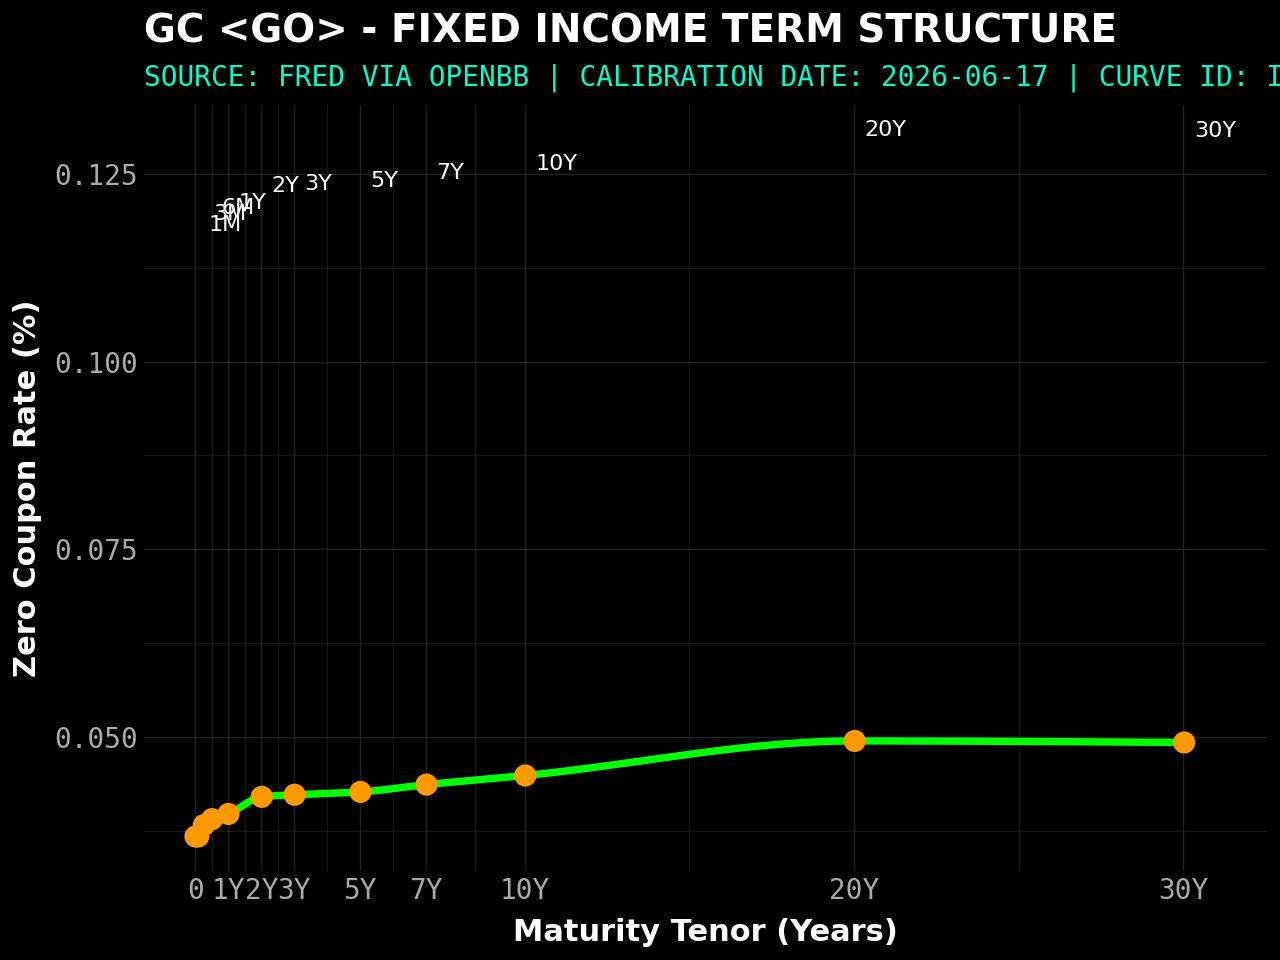

In [145]:

# 4. PLOTNINE CUSTOMIZATION (BLOOMBERG GRAPH CURVE 'GC' STYLE)
# -------------------------------------------------------------------------
bb_bg_color = '#000000'     # Matte Black Background
bb_grid_color = '#222222'   # Soft Faded Gridlines
bb_line_color = '#00FF00'   # Classic Terminal Neon Green
bb_node_color = '#FF9900'   # Amber Accent Constituents
bb_text_color = '#FFFFFF'   # High Contrast White Header

bb_theme = (
    theme_minimal()
    + theme(
        panel_background=element_rect(fill=bb_bg_color, color=bb_bg_color),
        plot_background=element_rect(fill=bb_bg_color, color=bb_bg_color),
        panel_grid_major=element_line(color=bb_grid_color, size=0.5),
        panel_grid_minor=element_line(color=bb_grid_color, size=0.25),
        axis_text=element_text(color='#AAAAAA', size=10, fontfamily='monospace'),
        axis_title=element_text(color=bb_text_color, size=11, fontweight='bold'),
        plot_title=element_text(color=bb_text_color, size=14, fontweight='bold', hjust=0),
        plot_subtitle=element_text(color='#00FFCC', size=10, fontfamily='monospace')
    )
)

bloomberg_gc_plot = (
    ggplot()
    + geom_line(data=df_continuous, mapping=aes(x='Maturity', y='Rate'), color=bb_line_color, size=1.5)
    + geom_point(data=df_nodes, mapping=aes(x='Maturity', y='Rate'), color=bb_node_color, size=3.5)
    + geom_text(data=df_labels, mapping=aes(x='Maturity', y='Rate', label='Label'), 
                color='#FFFFFF', va='bottom', ha='left', nudge_x=0.3, nudge_y=0.08, size=8)#, fontfamily='monospace')
    + bb_theme
    + scale_x_continuous(
        breaks=[0, 1, 2, 3, 5, 7, 10, 20, 30],
        labels=['0', '1Y', '2Y', '3Y', '5Y', '7Y', '10Y', '20Y', '30Y'],
        limits=[0, 31]
    )
    + labs(
        title="GC <GO> - FIXED INCOME TERM STRUCTURE",
        subtitle=f"SOURCE: FRED VIA OPENBB | CALIBRATION DATE: {eval_date_raw.strftime('%Y-%m-%d')} | CURVE ID: I25 US TREASURY ACTIVES",
        x="Maturity Tenor (Years)",
        y=Y_LABEL
    )
)

bloomberg_gc_plot


## Historical Curve


Notes: Watching Yield Curve
 - example, say 2Y-30Y, 2Y-30Y
 - metrics include: yield spread, momentum spread of moving averages crossing-over, price until moving averages
 - look at EMA (endpoint) scalar spread: 
   - past 6mo, 3mo, 2mo, etc.
   - (moving avg) weekly, monthly, 50-day, 200-day, 50-week, 200-week, 50-month, death-cross
 - despite large amounts of debt, everyone will need to buy more of as safe haven
 - 10Y-30Y (most marked) and 7Y-30Y peaked 2Sep2025


__US Treasury Futures Curve__

Extract the future interest rates that are locked in by today’s prevailing market prices.While a spot zero curve tells you the cost of borrowing money starting today for a given duration, a forward curve tells you the market's expected cost of borrowing money for a future period (for example, a 1-year loan that doesn't start until 2 years from now).In institutional finance and on the Bloomberg Terminal (via the FWCV function), the forward curve represents the break-even borrowing rates implied by the current spot curve.

__The Financial Intuition (An Example)__

Imagine you want to borrow money for two years. You have two choices:
* Strategy A (Spot): Borrow money for 2 years today at the current 2-year spot rate.
* Strategy B (Forward): Borrow money for 1 year today at the current 1-year spot rate. Simultaneously, lock in a contract to borrow money for another year, starting exactly 1 year from now.

To prevent institutional traders from making free, riskless money (arbitrage), Strategy A and Strategy B must cost the exact same amount. The rate required to make them equal is the 1-Year Forward Rate, 1 Year Effective (written notationally as 1Y × 1Y or 1Y1Y).

__Mathematical Definition__

Under continuous compounding, if you know the spot zero rate for a short maturity (T₁) and a longer maturity (T₂), the implied continuous forward rate (F) between those two dates is calculated as:

$F(T_{1},T_{2})=\frac{R(T_{2})\cdot T_{2}-R(T_{1})\cdot T_{1}}{T_{2}-T_{1}}$

* R(T) is the spot zero rate for time T.
* F(T₁, T₂) is the annualized forward rate starting at T₁ and ending at T₂.

__Spot Curve vs. Forward Curve Dynamics__

The relationship between the shape of the Treasury curve and the forward curve is mathematically strict. If you plot them side-by-side on a Bloomberg screen:

* When the Yield Curve is Upward Sloping: The forward curve will sit above the spot curve. This happens because the market is pricing in either rising interest rates or a higher term premium for locking in future money.
* When the Yield Curve is Flat: The forward curve and the spot curve will be perfectly identical.
* When the Yield Curve is Inverted (Downward Sloping): The forward curve will sit below the spot curve. This reflects a structural market expectation that the Federal Reserve will cut interest rates in the future.

__Usage on a Trading Desk__

* Monetary Policy Tracking: Macro traders look at the forward curve to see exactly when and by how much the market expects the Fed to move. For instance, looking at the 3-Month forward curve over the next two years maps out the exact trajectory of implied central bank rate cuts or hikes.

* Hedging and Derivatives Pricing: If an institutional corporation knows they will need to issue bonds in 6 months, they can use the forward curve to value and execute a forward-starting swap to lock in their borrowing costs today.

* Relative Value Trading: Fixed-income hedge funds look for "kinks" where the forward curve behaves unnaturally. If a specific forward rate looks mispriced relative to adjacent tenors, they will execute a roll-down or curve-steepening trade to exploit the anomaly.

In [147]:
#Extract a forward rate starting at year 2, ending at year 3
fwd_rate = yield_curve.forwardRate(2.0, 3.0, ql.Continuous, ql.Annual).rate() * 100
fwd_rate


0.04289796936955394

In [208]:
#historical rates
historical_rates_obj = auth.obb.fixedincome.government.treasury_rates(
    country="united_states", 
    start_date="1962-01-02",
    provider="federal_reserve"
)
df_rates = (
    historical_rates_obj.to_df() 
    if hasattr(historical_rates_obj, 'to_df') 
    else pd.DataFrame(historical_rates_obj)
)
df_rates.index = pd.to_datetime(df_rates.index)
#transform from wide to long
df_curve_from_historical = pd.melt(
    #df_rates.loc[['2026-06-11']].reset_index(),         # Reset index to make 'date' an accessible column
    df_rates.reset_index(),
    id_vars=['date'],               # Column(s) to keep as identifiers
    var_name='maturity',            # Name for the new column holding the old headers
    value_name='yield'              # Name for the new column holding the values
)
df_curve_from_historical.shape

(177100, 3)

In [210]:
df_curve_from_historical.head()

,date,maturity,yield
0,1962-01-02,year_1,0.0322
1,1962-01-03,year_1,0.0324
2,1962-01-04,year_1,0.0324
3,1962-01-05,year_1,0.0326
4,1962-01-08,year_1,0.0331


### Spot table

In [ ]:
import copy


def calculate_auc(row, yield_cols, x_values):
    """Calculate Area Under Curve"""
    #y_values = row[yield_cols].values
    y_values = [float(item) for item in row[yield_cols].values]
    # Exclude any NaNs to prevent AUC computation failure
    valid_mask = ~np.isnan(y_values)
    if np.sum(valid_mask) < 2:
        return np.nan
    y_values = np.array(y_values)
    return np.trapezoid(y_values[valid_mask], x_values[valid_mask])

def get_diff_curve_of_tenors(df_curve, tenor1, tenor2):
    """..."""
    ser1 = df_curve[df_curve['maturity']==tenor1][['date','yield']]
    ts1 = pd.Series(ser1['yield'].to_numpy(), index=ser1['date'].to_numpy())
    ser2 = df_curve[df_curve['maturity']==tenor2][['date','yield']]
    ts2 = pd.Series(ser2['yield'].to_numpy(), index=ser2['date'].to_numpy())
    ts3 = ts1 - ts2
    metric1 = Metric(ts3)
    #curve = metric1.ema(span=200) - metric1.ema(span=50)
    return metric1

def get_futures_interests_curve_analytics(df_curve_from_historical):
    """Get the metrics of futures interests curves."""
    tenors = ['year_30', 'year_10', 'year_7', 'year_5', 'year_3', 'year_2']
    results = {}
    
    #diff current
    current_date = df_curve_from_historical['date'].max()
    df_curve = df_curve_from_historical[df_curve_from_historical['date']==current_date]
    cache = {}
    for tenor in tenors:
        new_tenors = copy.deepcopy(tenors)
        new_tenors.remove(tenor)
        for other_tenor in new_tenors:
            key = f'{tenor}-{other_tenor}'
            contra_key = f'{other_tenor}-{tenor}'
            if key in cache.keys() or contra_key in cache.keys():
                continue
            else:
                result = df_curve[df_curve['maturity']==tenor]['yield'].iloc[0] - df_curve[df_curve['maturity']==other_tenor]['yield'].iloc[0]
                cache[key] = result#float(str(result * 100)[:6])
    diff_current = cache
    
    #diff curve metric
    df_curve = df_curve_from_historical
    cache = {}
    for tenor in tenors:
        new_tenors = copy.deepcopy(tenors)
        new_tenors.remove(tenor)
        for other_tenor in new_tenors:
            key = f'{tenor}-{other_tenor}'
            contra_key = f'{other_tenor}-{tenor}'
            if key in cache.keys() or contra_key in cache.keys():
                continue
            else:
                curve = get_diff_curve_of_tenors(df_curve, tenor, other_tenor)
                momentum = curve.ema(span=200) - curve.ema(span=50)
                current_day_momentum = momentum.iloc[momentum.shape[0]-1]
                prior_day_momentum = momentum.iloc[momentum.shape[0]-2]
                diff_current_minus_prior = current_day_momentum - prior_day_momentum
                #cache[key] = float(str(result * 100))
                cache[key] = {
                    'current_day_momentum': current_day_momentum,
                    'prior_day_momentum': prior_day_momentum,
                    'diff_current_minus_prior': diff_current_minus_prior
                }
    diff_curve_metric = cache

    #area under curve
    # Extract the numeric values from the column names (e.g., 'month_1', 'year_10')
    # Assume standard years/months as fractions: 1mo=1/12, 1y=1, 10y=10, etc.
    term_map = {
        'month_1': 1/12, 'month_2': 2/12, 'month_3': 3/12, 'month_4': 4/12, 'month_6': 6/12, 'year_1': 1,
        'year_2': 2, 'year_3': 3, 'year_5': 5, 'year_7': 7, 'year_10': 10, 'year_20': 20, 'year_30': 30
    }
    df_wide = df_curve_from_historical.reset_index().pivot(
        index='date', 
        columns='maturity', 
        values='yield'
    ).reset_index()
    yield_cols = [col for col in df_wide.columns if col in term_map] 
    x_values = np.array([term_map[col] for col in yield_cols])
    df_wide['AUC'] = df_wide.apply(calculate_auc, axis=1, args=(yield_cols, x_values))

    results = {
        'diff_current': diff_current,
        'diff_curve_metric': diff_curve_metric,
        'auc': df_wide['AUC']
    } 
    return results


results = get_futures_interests_curve_analytics(df_curve_from_historical)

### Create Graph

* Get curve by subtracting by each unit
* Diff (delta): 200dayMA - 50dayMA
* graph

### Create Table

* Forward curves, with Prior Day
* Diff (delta): 200dayMA - 50dayMA
* either pos or negative

### Area Under Curve (Howell)